# 10 - Reservation Objective Functions

This notebook defines a few scoring rules for strict Class 1 reservation and compares them to pooled FCFS on a small matched example.

Each rule turns one simulation run into one number. A higher number means the policy looks better under that rule. The rules here answer different practical questions:

- Are more appointment slots actually booked instead of left empty?
- Are more slots booked by the class we care about?
- Are more patients served after giving Class 1 extra weight?
- Does strict reservation still look good after charging a cost for protected slots?
- Does it still look good after also charging a cost for longer waits?
- Does it pass basic requirements, like booking at least half the slots and not letting the two classes get too far apart?

Here `Q = reserved_slots_per_day` is the number of protected Class 1 slots per day. In this reservation analysis, the main utilization concept is booked-slot utilization: booked appointment slots divided by available slots.


In [1]:
from __future__ import annotations

from dataclasses import replace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_dir(start: Path) -> Path:
    current = Path(start).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "simulation" / "engine.py").exists() and (
            candidate / "analysis" / "metrics.py"
        ).exists():
            return candidate
    raise FileNotFoundError("Could not find the repository root from the current notebook location.")


REPO_DIR = find_repo_dir(Path.cwd())
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

from analysis.metrics import aggregate_result_row, class_result_rows
from simulation.engine import ClinicAppointmentSimulation
from simulation.model import PatientClassParams, SimulationConfig, ThresholdRule

plt.style.use("default")

## Objective Parameters

The baseline demand used here is 25 arrivals per day across both classes. The Class 1 share is set to 0.58, close to the realistic configuration where Class 1 has 14 arrivals/day and Class 2 has 10 arrivals/day.

The headline comparison uses Class 1 weight 1.5, slot cost 0.05, and wait penalty 0.05. The other values are sensitivity checks around that starting point.


In [2]:
BASELINE_TOTAL_DEMAND = 25.0
BASELINE_CLASS_1_SHARE = 0.58
BASELINE_SLOTS_PER_DAY = 20
BASELINE_RESERVED_SLOTS_PER_DAY = 5

CLASS_1_WEIGHTS = [1.0, 1.25, 1.5, 2.0, 3.0]
CLASS_2_WEIGHT = 1.0
SLOT_COSTS = [0.0, 0.02, 0.05, 0.10]
WAIT_PENALTIES = [0.0, 0.02, 0.05, 0.10]

UTILIZATION_FLOORS = [0.50, 0.75, 0.85, 0.90]
SERVED_RATE_FLOORS = [0.45, 0.55, 0.65, 0.70]
CLASS_UTILIZATION_GAP_LIMITS = [0.10, 0.20, 0.30]

MAIN_CLASS_1_WEIGHT = 1.5
MAIN_SLOT_COST = 0.05
MAIN_WAIT_PENALTY = 0.05
MAIN_NET_WAIT_PENALTY = 0.0
MAIN_UTILIZATION_FLOOR = 0.85
MAIN_SERVED_RATE_FLOOR = 0.55
MAIN_CLASS_UTILIZATION_GAP_LIMIT = 0.20

parameter_grid = pd.DataFrame(
    {
        "class_1_weights": pd.Series(CLASS_1_WEIGHTS),
        "slot_costs": pd.Series(SLOT_COSTS),
        "wait_penalties": pd.Series(WAIT_PENALTIES),
        "utilization_floors": pd.Series(UTILIZATION_FLOORS),
        "served_rate_floors": pd.Series(SERVED_RATE_FLOORS),
        "class_utilization_gap_limits": pd.Series(CLASS_UTILIZATION_GAP_LIMITS),
    }
)

headline_parameters = pd.Series(
    {
        "baseline_total_demand": BASELINE_TOTAL_DEMAND,
        "baseline_class_1_share": BASELINE_CLASS_1_SHARE,
        "baseline_slots_per_day": BASELINE_SLOTS_PER_DAY,
        "baseline_reserved_slots_per_day": BASELINE_RESERVED_SLOTS_PER_DAY,
        "main_class_1_weight": MAIN_CLASS_1_WEIGHT,
        "main_slot_cost": MAIN_SLOT_COST,
        "main_wait_penalty": MAIN_WAIT_PENALTY,
        "main_utilization_floor": MAIN_UTILIZATION_FLOOR,
        "main_served_rate_floor": MAIN_SERVED_RATE_FLOOR,
        "main_class_utilization_gap_limit": MAIN_CLASS_UTILIZATION_GAP_LIMIT,
    },
    name="value",
).to_frame()

display(parameter_grid)
display(headline_parameters)


,class_1_weights,slot_costs,wait_penalties,utilization_floors,served_rate_floors,class_utilization_gap_limits
0,1.00,0.00,0.00,0.50,0.45,0.1
1,1.25,0.02,0.02,0.75,0.55,0.2
2,1.50,0.05,0.05,0.85,0.65,0.3
3,2.00,0.10,0.10,0.90,0.70,NaN
4,3.00,NaN,NaN,NaN,NaN,NaN


,value
baseline_total_demand,25.00
baseline_class_1_share,0.58
baseline_slots_per_day,20.00
baseline_reserved_slots_per_day,5.00
main_class_1_weight,1.50
main_slot_cost,0.05
main_wait_penalty,0.05
main_utilization_floor,0.85
main_served_rate_floor,0.55
main_class_utilization_gap_limit,0.20


## Small Example Setup

This notebook uses the baseline-size example so the formulas can be checked quickly before running the larger sweep. The example has 20 slots per day, about 25 arrivals per day, and `Q = 5` protected Class 1 slots.


In [3]:
BASE_SCENARIO = {
    "slots_per_day": BASELINE_SLOTS_PER_DAY,
    "reserved_slots_per_day": BASELINE_RESERVED_SLOTS_PER_DAY,
    "reserved_class_id": 1,
    "horizon_days": 28,
    "burn_in_days": 60,
    "measure_days": 365,
    "cooldown_days": 30,
    "seeds": list(range(5101, 5111)),
    "classes": {
        1: {
            "lambda_per_day": round(BASELINE_TOTAL_DEMAND * BASELINE_CLASS_1_SHARE, 4),
            "cancel_prob": 0.01,
            "value": 1.0,
            "balk_prob": {"threshold": 21, "low": 0.02, "high": 0.55},
            "no_show_prob": {"threshold": 21, "low": 0.01, "high": 0.31},
        },
        2: {
            "lambda_per_day": round(BASELINE_TOTAL_DEMAND * (1 - BASELINE_CLASS_1_SHARE), 4),
            "cancel_prob": 0.02,
            "value": 1.0,
            "balk_prob": {"threshold": 14, "low": 0.04, "high": 0.72},
            "no_show_prob": {"threshold": 14, "low": 0.15, "high": 0.51},
        },
    },
}


def build_config(scenario: dict, *, q: int, seed: int | None) -> SimulationConfig:
    classes = {}
    for class_id, params in scenario["classes"].items():
        classes[class_id] = PatientClassParams(
            class_id=class_id,
            lambda_per_day=float(params["lambda_per_day"]),
            balk_prob=ThresholdRule(**params["balk_prob"]),
            cancel_prob=float(params["cancel_prob"]),
            no_show_prob=ThresholdRule(**params["no_show_prob"]),
            value=float(params.get("value", 1.0)),
        )

    return SimulationConfig(
        slots_per_day=int(scenario["slots_per_day"]),
        horizon_days=int(scenario["horizon_days"]),
        burn_in_days=int(scenario["burn_in_days"]),
        measure_days=int(scenario["measure_days"]),
        cooldown_days=int(scenario["cooldown_days"]),
        classes=classes,
        seed=seed,
        reserved_class_id=scenario["reserved_class_id"] if q > 0 else None,
        reserved_slots_per_day=int(q),
    )


pd.Series({key: value for key, value in BASE_SCENARIO.items() if key not in {"classes", "seeds"}}, name="value").to_frame()


,value
slots_per_day,20
reserved_slots_per_day,5
reserved_class_id,1
horizon_days,28
burn_in_days,60
measure_days,365
cooldown_days,30


## Run Summaries

Each simulation run is turned into one row with the totals needed for the scoring rules: arrivals, served patients, waiting time, booked slot use, completed slot use, and losses.


In [4]:
def safe_divide(numerator: float, denominator: float) -> float:
    return numerator / denominator if denominator else 0.0


def result_summary_row(result, fixed_values: dict) -> dict:
    aggregate = aggregate_result_row(result, fixed_values)
    class_df = pd.DataFrame(class_result_rows(result, fixed_values)).set_index("class_id")
    c1 = class_df.loc[1]
    c2 = class_df.loc[2]
    total_arrivals = aggregate["total_arrivals"]
    total_offered = aggregate["total_offered"]

    return {
        **fixed_values,
        "slots_per_day": result.total_slots / result.slot_metrics.measured_days,
        "horizon_days": result.final_full_state and len(result.final_full_state) or np.nan,
        "total_arrivals": total_arrivals,
        "total_served": aggregate["total_served"],
        "total_offered": total_offered,
        "total_booked_slots": aggregate["total_booked_slots"],
        "total_served_slots": aggregate["total_served_slots"],
        "total_no_show_slots": aggregate["total_no_show_slots"],
        "served_rate": safe_divide(aggregate["total_served"], total_arrivals),
        "average_utilization": aggregate["average_utilization"],
        "booked_slot_utilization": aggregate["booked_slot_utilization"],
        "mean_offered_booking_delay": aggregate["mean_offered_booking_delay"],
        "total_balked": aggregate["total_balked"],
        "total_no_offer": aggregate["total_no_offer"],
        "total_canceled": aggregate["total_canceled"],
        "total_no_show": aggregate["total_no_show"],
        "total_unresolved_booked": aggregate["total_unresolved_booked"],
        "class_1_arrivals": c1["arrivals"],
        "class_2_arrivals": c2["arrivals"],
        "class_1_served": c1["served"],
        "class_2_served": c2["served"],
        "class_1_no_show": c1["no_show"],
        "class_2_no_show": c2["no_show"],
        "class_1_offered": c1["offered"],
        "class_2_offered": c2["offered"],
        "class_1_served_rate": c1["percent_serviced"],
        "class_2_served_rate": c2["percent_serviced"],
        "min_class_served_rate": min(c1["percent_serviced"], c2["percent_serviced"]),
        "class_1_slot_utilization": c1["slot_utilization"],
        "class_2_slot_utilization": c2["slot_utilization"],
        "class_utilization_gap": abs(c1["slot_utilization"] - c2["slot_utilization"]),
        "class_1_booked_slot_utilization": c1["booked_slot_utilization"],
        "class_2_booked_slot_utilization": c2["booked_slot_utilization"],
        "class_booked_slot_utilization_gap": abs(c1["booked_slot_utilization"] - c2["booked_slot_utilization"]),
        "class_1_total_offered_delay": c1["total_offered_booking_delay"],
        "class_2_total_offered_delay": c2["total_offered_booking_delay"],
    }


def validate_accounting(row: pd.Series) -> None:
    partition = (
        row["total_served"]
        + row["total_balked"]
        + row["total_no_offer"]
        + row["total_canceled"]
        + row["total_no_show"]
        + row["total_unresolved_booked"]
    )
    if abs(partition - row["total_arrivals"]) > 1e-9:
        raise AssertionError("Outcomes do not partition arrivals.")


## Objective Functions

The formulas below are the comparison rules. Each one gives one number for FCFS and one number for strict reservation.

The notation follows the TeX reference files: $S$ is daily capacity, $H$ is the booking horizon, $Q$ is protected Class 1 capacity, $
\lambda_i$ is the class-$i$ arrival rate, and $\tau$ is the offered delay. The reference note keeps completed-visit utilization as $\rho^{\mathrm{attended}}$. For this reservation analysis, we also use booked-slot utilization:

$$
\rho^{\mathrm{booked}}
=
\frac{\mathrm{booked\ slots\ on\ service\ days}}{S\times\mathrm{measured\ days}},
\qquad
\rho^{\mathrm{attended}}
=
\frac{\mathrm{served\ slots}}{S\times\mathrm{measured\ days}}.
$$

Booked-slot utilization is the main capacity measure here because unused protected slots reduce it. A no-show still counts as a booked slot because the appointment occupied the schedule. A cancellation only counts if the slot is still booked on the service day.

For class-specific booked slot use, the notebook uses each class contribution:

$$
\rho_i^{\mathrm{booked}}
=
\frac{\mathrm{served}_i+\mathrm{no\ show}_i}{S\times\mathrm{measured\ days}}.
$$

The weighted booked-slot rule asks: how much of the calendar was booked by each class, after giving Class 1 more or less importance?

$$
U_{\mathrm{booked}}(w_1,w_2) = w_1 \rho_1^{\mathrm{booked}} + w_2 \rho_2^{\mathrm{booked}}.
$$

The weighted served-rate rule asks: out of weighted demand, what share got served?

$$
U_{\mathrm{served}}(w_1,w_2) = \frac{w_1 \mathrm{served}_1 + w_2 \mathrm{served}_2}{w_1 \mathrm{arrivals}_1 + w_2 \mathrm{arrivals}_2}.
$$

The slot-cost rule asks: does the policy still look good after charging a cost for protecting slots?

$$
U_{\mathrm{net\ booked}}(w_1,w_2,c) = U_{\mathrm{booked}}(w_1,w_2) - c\frac{Q}{S}.
$$

The wait-adjusted rule asks: does the policy still look good after also charging a cost for longer offered waits? First compute the weighted average offered delay, using the same $\tau$ notation as the TeX notes:

$$
\bar\tau_w = \frac{w_1 \sum_{\mathrm{offered\ class\ 1}} \tau + w_2 \sum_{\mathrm{offered\ class\ 2}} \tau}{w_1 \mathrm{offered}_1 + w_2 \mathrm{offered}_2},
$$

Then subtract a wait penalty:

$$
U_{\mathrm{wait}}(w_1,w_2,c,\gamma) = U_{\mathrm{booked}}(w_1,w_2) - c\frac{Q}{S} - \gamma\frac{\bar\tau_w}{H}.
$$

The rule-based version asks a different question: among policies that pass basic requirements, which one has the best booked slot use or shortest wait? The requirements are:

$$
\rho^{\mathrm{booked}} \ge \rho_{\mathrm{min}}, \qquad \min_i\ \mathrm{served\ rate}_i \ge x, \qquad |\rho_1^{\mathrm{booked}}-\rho_2^{\mathrm{booked}}| \le g.
$$

Here $\rho_{\mathrm{min}}$ is the minimum booked-slot level, $x$ is the minimum served rate for each class, and $g$ is the largest allowed class booked-slot gap.


In [5]:
def weighted_mean_offered_delay(row: pd.Series, class_1_weight: float, class_2_weight: float = CLASS_2_WEIGHT) -> float:
    weighted_delay = (
        class_1_weight * row["class_1_total_offered_delay"]
        + class_2_weight * row["class_2_total_offered_delay"]
    )
    weighted_offered = (
        class_1_weight * row["class_1_offered"]
        + class_2_weight * row["class_2_offered"]
    )
    return safe_divide(weighted_delay, weighted_offered)


def score_rows_for_run(row: pd.Series) -> list[dict]:
    rows = []
    q_share = safe_divide(row["Q"], row["slots_per_day"])

    rows.append({**row.to_dict(), "score_name": "served_rate", "class_1_weight": 1.0, "slot_cost": 0.0, "wait_penalty": 0.0, "score_value": row["served_rate"]})
    rows.append({**row.to_dict(), "score_name": "booked_slot_utilization", "class_1_weight": 1.0, "slot_cost": 0.0, "wait_penalty": 0.0, "score_value": row["booked_slot_utilization"]})

    for weight in CLASS_1_WEIGHTS:
        weighted_served_rate = safe_divide(
            weight * row["class_1_served"] + CLASS_2_WEIGHT * row["class_2_served"],
            weight * row["class_1_arrivals"] + CLASS_2_WEIGHT * row["class_2_arrivals"],
        )
        weighted_attended_slot_score = (
            weight * row["class_1_slot_utilization"]
            + CLASS_2_WEIGHT * row["class_2_slot_utilization"]
        )
        weighted_booked_slot_score = (
            weight * row["class_1_booked_slot_utilization"]
            + CLASS_2_WEIGHT * row["class_2_booked_slot_utilization"]
        )
        weighted_delay = weighted_mean_offered_delay(row, weight)

        rows.append({**row.to_dict(), "score_name": "weighted_served_rate", "class_1_weight": weight, "slot_cost": 0.0, "wait_penalty": 0.0, "score_value": weighted_served_rate})
        rows.append({**row.to_dict(), "score_name": "weighted_attended_slot_score", "class_1_weight": weight, "slot_cost": 0.0, "wait_penalty": 0.0, "score_value": weighted_attended_slot_score})
        rows.append({**row.to_dict(), "score_name": "weighted_booked_slot_score", "class_1_weight": weight, "slot_cost": 0.0, "wait_penalty": 0.0, "score_value": weighted_booked_slot_score})

        for slot_cost in SLOT_COSTS:
            rows.append({**row.to_dict(), "score_name": "net_priority_score", "class_1_weight": weight, "slot_cost": slot_cost, "wait_penalty": 0.0, "score_value": weighted_served_rate - slot_cost * q_share})
            rows.append({**row.to_dict(), "score_name": "net_booked_slot_score", "class_1_weight": weight, "slot_cost": slot_cost, "wait_penalty": 0.0, "score_value": weighted_booked_slot_score - slot_cost * q_share})

            for wait_penalty in WAIT_PENALTIES:
                delay_cost = wait_penalty * safe_divide(weighted_delay, row["horizon_days"])
                rows.append({**row.to_dict(), "score_name": "wait_adjusted_booked_slot_score", "class_1_weight": weight, "slot_cost": slot_cost, "wait_penalty": wait_penalty, "score_value": weighted_booked_slot_score - slot_cost * q_share - delay_cost})

    return rows


def rule_rows_for_run(row: pd.Series) -> list[dict]:
    rows = []
    for utilization_floor in UTILIZATION_FLOORS:
        for served_floor in SERVED_RATE_FLOORS:
            for gap_limit in CLASS_UTILIZATION_GAP_LIMITS:
                passes_rules = (
                    row["booked_slot_utilization"] >= utilization_floor
                    and row["min_class_served_rate"] >= served_floor
                    and row["class_booked_slot_utilization_gap"] <= gap_limit
                )
                rows.append(
                    {
                        **row.to_dict(),
                        "utilization_floor": utilization_floor,
                        "served_rate_floor": served_floor,
                        "class_utilization_gap_limit": gap_limit,
                        "passes_rules": passes_rules,
                        "utilization_if_rules_pass": row["booked_slot_utilization"] if passes_rules else np.nan,
                        "wait_score_if_rules_pass": -row["mean_offered_booking_delay"] if passes_rules else np.nan,
                    }
                )
    return rows


## Matched FCFS Example

Run FCFS and strict reservation with the same seeds. This makes the comparison cleaner because both policies see the same random starting points.


In [6]:
run_rows = []
for seed in BASE_SCENARIO["seeds"]:
    for policy, q in [("Pooled FCFS", 0), ("Strict C1 reservation", BASE_SCENARIO["reserved_slots_per_day"] )]:
        config = build_config(BASE_SCENARIO, q=q, seed=int(seed))
        result = ClinicAppointmentSimulation(config).run()
        fixed = {"policy": policy, "seed": int(seed), "Q": int(q)}
        run_rows.append(result_summary_row(result, fixed))

run_df = pd.DataFrame(run_rows)
run_df.apply(validate_accounting, axis=1)

score_df = pd.DataFrame([objective for _, row in run_df.iterrows() for objective in score_rows_for_run(row)])
rule_df = pd.DataFrame([constraint for _, row in run_df.iterrows() for constraint in rule_rows_for_run(row)])

display(run_df.groupby("policy")[["served_rate", "booked_slot_utilization", "average_utilization", "mean_offered_booking_delay", "class_1_served_rate", "class_2_served_rate", "class_booked_slot_utilization_gap"]].mean().round(4))
display(score_df.head())
display(rule_df.head())


,served_rate,booked_slot_utilization,average_utilization,mean_offered_booking_delay,class_1_served_rate,class_2_served_rate,class_booked_slot_utilization_gap
policy,,,,,,,
Pooled FCFS,0.7551,1.0,0.9352,12.4531,0.8651,0.6027,0.2592
Strict C1 reservation,0.7541,1.0,0.9346,12.4506,0.8653,0.5999,0.2608


,policy,seed,Q,slots_per_day,horizon_days,total_arrivals,total_served,total_offered,total_booked_slots,total_served_slots,...,class_1_booked_slot_utilization,class_2_booked_slot_utilization,class_booked_slot_utilization_gap,class_1_total_offered_delay,class_2_total_offered_delay,score_name,class_1_weight,slot_cost,wait_penalty,score_value
0,Pooled FCFS,5101,0,20.0,28,9009,6873,9009,7300,6835,...,0.626986,0.379726,0.24726,64609.0,45380.0,served_rate,1.0,0.0,0.0,0.762904
1,Pooled FCFS,5101,0,20.0,28,9009,6873,9009,7300,6835,...,0.626986,0.379726,0.24726,64609.0,45380.0,booked_slot_utilization,1.0,0.0,0.0,1.000000
2,Pooled FCFS,5101,0,20.0,28,9009,6873,9009,7300,6835,...,0.626986,0.379726,0.24726,64609.0,45380.0,weighted_served_rate,1.0,0.0,0.0,0.762904
3,Pooled FCFS,5101,0,20.0,28,9009,6873,9009,7300,6835,...,0.626986,0.379726,0.24726,64609.0,45380.0,weighted_attended_slot_score,1.0,0.0,0.0,0.941507
4,Pooled FCFS,5101,0,20.0,28,9009,6873,9009,7300,6835,...,0.626986,0.379726,0.24726,64609.0,45380.0,weighted_booked_slot_score,1.0,0.0,0.0,1.006712


,policy,seed,Q,slots_per_day,horizon_days,total_arrivals,total_served,total_offered,total_booked_slots,total_served_slots,...,class_2_booked_slot_utilization,class_booked_slot_utilization_gap,class_1_total_offered_delay,class_2_total_offered_delay,utilization_floor,served_rate_floor,class_utilization_gap_limit,passes_rules,utilization_if_rules_pass,wait_score_if_rules_pass
0,Pooled FCFS,5101,0,20.0,28,9009,6873,9009,7300,6835,...,0.379726,0.24726,64609.0,45380.0,0.5,0.45,0.1,False,NaN,NaN
1,Pooled FCFS,5101,0,20.0,28,9009,6873,9009,7300,6835,...,0.379726,0.24726,64609.0,45380.0,0.5,0.45,0.2,False,NaN,NaN
2,Pooled FCFS,5101,0,20.0,28,9009,6873,9009,7300,6835,...,0.379726,0.24726,64609.0,45380.0,0.5,0.45,0.3,True,1.0,-12.208791
3,Pooled FCFS,5101,0,20.0,28,9009,6873,9009,7300,6835,...,0.379726,0.24726,64609.0,45380.0,0.5,0.55,0.1,False,NaN,NaN
4,Pooled FCFS,5101,0,20.0,28,9009,6873,9009,7300,6835,...,0.379726,0.24726,64609.0,45380.0,0.5,0.55,0.2,False,NaN,NaN


## Checks

These checks make sure the notebook is comparing sensible numbers: FCFS has no protected slots, weighted served rates stay between 0 and 1, booked-slot utilization stays between 0 and 1, and higher slot costs do not make a policy look better.


In [7]:
assert (run_df.loc[run_df["policy"] == "Pooled FCFS", "Q"] == 0).all(), "FCFS must have Q = 0."
assert score_df.loc[score_df["policy"] == "Pooled FCFS", "slot_cost"].ge(0).all(), "Slot costs should be nonnegative."

booked_scores = score_df[score_df["score_name"] == "booked_slot_utilization"]
assert booked_scores["score_value"].between(0, 1).all(), "Booked-slot utilization must be in [0, 1]."

weighted_served = score_df[score_df["score_name"] == "weighted_served_rate"]
assert weighted_served["score_value"].between(0, 1).all(), "Weighted served score must be in [0, 1]."

for score_name in ["net_priority_score", "net_booked_slot_score"]:
    net = score_df[score_df["score_name"] == score_name].sort_values("slot_cost")
    monotone = net.groupby(["policy", "seed", "Q", "class_1_weight"])["score_value"].apply(lambda s: s.diff().dropna().le(1e-12).all())
    assert monotone.all(), f"Higher slot-cost penalties should not increase {score_name}."

fcfs_by_cost = score_df[score_df["policy"] == "Pooled FCFS"].groupby(["score_name", "seed", "class_1_weight", "wait_penalty"])
for _, group in fcfs_by_cost:
    if group["slot_cost"].nunique() > 1:
        assert group["score_value"].nunique() == 1, "FCFS score should not change with slot cost because Q = 0."

print("Score checks passed.")


Score checks passed.


## Difference From FCFS

The table below reports strict reservation minus FCFS. Positive values mean strict reservation did better under that scoring rule. Negative values mean FCFS did better.


In [8]:
paired = score_df.pivot_table(
    index=["seed", "score_name", "class_1_weight", "slot_cost", "wait_penalty"],
    columns="policy",
    values="score_value",
).reset_index()
paired["difference_vs_fcfs"] = paired["Strict C1 reservation"] - paired["Pooled FCFS"]

difference_summary = (
    paired.groupby(["score_name", "class_1_weight", "slot_cost", "wait_penalty"])["difference_vs_fcfs"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
difference_summary["sem"] = difference_summary["std"].fillna(0.0) / np.sqrt(difference_summary["count"])
difference_summary["ci_low"] = difference_summary["mean"] - 1.96 * difference_summary["sem"]
difference_summary["ci_high"] = difference_summary["mean"] + 1.96 * difference_summary["sem"]
difference_summary["classification"] = np.select(
    [
        (difference_summary["mean"] > 0) & (difference_summary["ci_low"] > 0),
        difference_summary["mean"] > 0,
    ],
    ["win", "possible_win"],
    default="loss",
)

headline_rows = difference_summary[
    (
        (difference_summary["score_name"] == "net_booked_slot_score")
        & (difference_summary["class_1_weight"] == MAIN_CLASS_1_WEIGHT)
        & (difference_summary["slot_cost"] == MAIN_SLOT_COST)
        & (difference_summary["wait_penalty"] == MAIN_NET_WAIT_PENALTY)
    )
    | (
        (difference_summary["score_name"] == "wait_adjusted_booked_slot_score")
        & (difference_summary["class_1_weight"] == MAIN_CLASS_1_WEIGHT)
        & (difference_summary["slot_cost"] == MAIN_SLOT_COST)
        & (difference_summary["wait_penalty"] == MAIN_WAIT_PENALTY)
    )
    | (difference_summary["score_name"].isin(["served_rate", "booked_slot_utilization"]))
]

display(headline_rows.sort_values(["score_name", "class_1_weight", "slot_cost", "wait_penalty"]))
display(difference_summary.sort_values(["score_name", "class_1_weight", "slot_cost", "wait_penalty"]).head(20))


,score_name,class_1_weight,slot_cost,wait_penalty,mean,std,count,sem,ci_low,ci_high,classification
0,booked_slot_utilization,1.0,0.00,0.00,0.00000,0.000000,10,0.000000,0.000000,0.000000,loss
11,net_booked_slot_score,1.5,0.05,0.00,-0.01211,0.006315,10,0.001997,-0.016023,-0.008196,loss
41,served_rate,1.0,0.00,0.00,-0.00100,0.013627,10,0.004309,-0.009446,0.007447,loss
84,wait_adjusted_booked_slot_score,1.5,0.05,0.05,-0.01208,0.006001,10,0.001898,-0.015800,-0.008361,loss


,score_name,class_1_weight,slot_cost,wait_penalty,mean,std,count,sem,ci_low,ci_high,classification
0,booked_slot_utilization,1.00,0.00,0.0,0.000000,0.000000,10,0.000000,0.000000,0.000000,loss
1,net_booked_slot_score,1.00,0.00,0.0,-0.000014,0.001968,10,0.000622,-0.001233,0.001206,loss
2,net_booked_slot_score,1.00,0.02,0.0,-0.005014,0.001968,10,0.000622,-0.006233,-0.003794,loss
3,net_booked_slot_score,1.00,0.05,0.0,-0.012514,0.001968,10,0.000622,-0.013733,-0.011294,loss
4,net_booked_slot_score,1.00,0.10,0.0,-0.025014,0.001968,10,0.000622,-0.026233,-0.023794,loss
5,net_booked_slot_score,1.25,0.00,0.0,0.000188,0.003505,10,0.001108,-0.001984,0.002361,possible_win
6,net_booked_slot_score,1.25,0.02,0.0,-0.004812,0.003505,10,0.001108,-0.006984,-0.002639,loss
7,net_booked_slot_score,1.25,0.05,0.0,-0.012312,0.003505,10,0.001108,-0.014484,-0.010139,loss
8,net_booked_slot_score,1.25,0.10,0.0,-0.024812,0.003505,10,0.001108,-0.026984,-0.022639,loss
9,net_booked_slot_score,1.50,0.00,0.0,0.000390,0.006315,10,0.001997,-0.003523,0.004304,possible_win


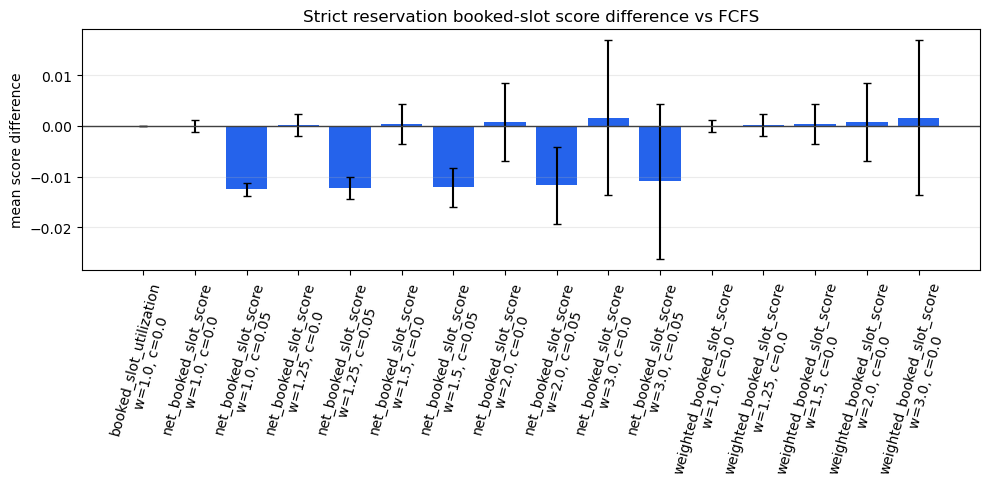

In [9]:
plot_df = difference_summary[
    (difference_summary["score_name"].isin(["booked_slot_utilization", "weighted_booked_slot_score", "net_booked_slot_score"]))
    & (difference_summary["wait_penalty"] == MAIN_NET_WAIT_PENALTY)
    & (difference_summary["slot_cost"].isin([0.0, MAIN_SLOT_COST]))
].copy()
plot_df["label"] = plot_df.apply(lambda row: f"{row['score_name']}\nw={row['class_1_weight']}, c={row['slot_cost']}", axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(plot_df["label"], plot_df["mean"], yerr=1.96 * plot_df["sem"], capsize=3, color="#2563eb")
ax.axhline(0, color="0.25", linewidth=1)
ax.set_title("Strict reservation booked-slot score difference vs FCFS")
ax.set_ylabel("mean score difference")
ax.tick_params(axis="x", rotation=75)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
